In [ ]:
from datasets import load_dataset, concatenate_datasets, ClassLabel, Features, Image, Value
from collections import Counter
from tqdm import tqdm
from pathlib import Path

import pandas as pd
import os
import json
import kagglehub
import json
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import math

# 1. 원본데이터셋 다운로드 및 샘플링

In [ ]:
ds = load_dataset("Parveshiiii/AI-vs-Real")
train = ds["train"]

print("rows:", len(train))
print("columns:", train.column_names)
print(train.features)

rows: 13999
columns: ['image', 'binary_label']
{'image': Image(mode=None, decode=True), 'binary_label': Value('int64')}


In [ ]:
ds = load_dataset("Parveshiiii/AI-vs-Real")["train"]

ai = ds.filter(lambda x: x["binary_label"] == 0).shuffle(seed=42).select(range(1000))
real = ds.filter(lambda x: x["binary_label"] == 1).shuffle(seed=42).select(range(1000))

small = concatenate_datasets([ai, real]).shuffle(seed=42)
print("Small dataset size:", len(small), Counter(small["binary_label"]))

Filter:   0%|          | 0/13999 [00:00<?, ? examples/s]

Filter:   0%|          | 0/13999 [00:00<?, ? examples/s]

Small dataset size: 2000 Counter({1: 1000, 0: 1000})


In [ ]:
new_features = Features({
    "image": Image(decode=True),
    "binary_label": ClassLabel(names=["ai", "real"])  # 0=ai, 1=real
})

small = small.cast(new_features)

print("After cast:", small.features)


Casting the dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

After cast: {'image': Image(mode=None, decode=True), 'binary_label': ClassLabel(names=['ai', 'real'])}


In [ ]:
split = small.train_test_split(
    test_size=0.2,
    seed=42,
    stratify_by_column="binary_label"
)
train_ds = split["train"]
test_ds = split["test"]

print("Train:", len(train_ds), Counter(train_ds["binary_label"]))
print("Test :", len(test_ds), Counter(test_ds["binary_label"]))

Train: 1600 Counter({0: 800, 1: 800})
Test : 400 Counter({0: 200, 1: 200})


In [ ]:
def save_split(dataset, base_dir):
    ai_dir = os.path.join(base_dir, "ai")
    real_dir = os.path.join(base_dir, "real")
    os.makedirs(ai_dir, exist_ok=True)
    os.makedirs(real_dir, exist_ok=True)

    ai_idx = 0
    real_idx = 0

    for i in tqdm(range(len(dataset)), desc=f"Saving {base_dir}"):
        row = dataset[i]
        img = row["image"].convert("RGB")
        label = row["binary_label"]  # ClassLabel로 캐스팅된 뒤에도 0/1로 들어옴

        if label == 0:
            img.save(os.path.join(ai_dir, f"{ai_idx:06d}.jpg"), "JPEG", quality=95)
            ai_idx += 1
        else:
            img.save(os.path.join(real_dir, f"{real_idx:06d}.jpg"), "JPEG", quality=95)
            real_idx += 1

    print(f"{base_dir}: ai={ai_idx}, real={real_idx}")

save_split(train_ds, "AI-vs-Real/train")
save_split(test_ds, "AI-vs-Real/test")

Saving AI-vs-Real/train: 100%|██████████| 1600/1600 [00:15<00:00, 103.73it/s]


AI-vs-Real/train: ai=800, real=800


Saving AI-vs-Real/test: 100%|██████████| 400/400 [00:03<00:00, 112.72it/s]

AI-vs-Real/test: ai=200, real=200


In [ ]:
base = Path("AI-vs-Real")  # 로컬 폴더 기준으로 생성해도 OK (Hub 구조와 동일)

records = []
for split in ["train", "test"]:
    for cls, label in [("ai", 0), ("real", 1)]:
        folder = base / split / cls
        for p in sorted(folder.glob("*")):
            if p.is_file():
                rel_path = str(p.relative_to(base)).replace("\\", "/")
                records.append({
                    "img_path": rel_path,        # 예: train/ai/000123.jpg
                    "binary_label": label,
                    "split": split
                })

with open("ai_vs_real_meta.json", "w", encoding="utf-8") as f:
    json.dump(records, f, ensure_ascii=False, indent=2)

print("saved meta.json:", len(records))

saved meta.json: 2000


In [ ]:
with open("ai_vs_real_meta.json", "r", encoding="utf-8") as f:
    data = json.load(f)

df = pd.DataFrame(data)
df.head()

,img_path,binary_label,split
0,train/ai/000000.jpg,0,train
1,train/ai/000001.jpg,0,train
2,train/ai/000002.jpg,0,train
3,train/ai/000003.jpg,0,train
4,train/ai/000004.jpg,0,train


- 이후 Kaggle command로 Kaggle에 업로드

# 2. 데이터셋 전처리

In [ ]:
# kaggle로 데이터 다운 받기 
path = kagglehub.dataset_download("haeunkim8812/ai-vs-real-2k-images")

print("데이터가 저장된 파일 경로:", path)

100%|██████████| 409M/409M [00:13<00:00, 32.6MB/s] 

Extracting files...


데이터가 저장된 파일 경로: /root/.cache/kagglehub/datasets/haeunkim8812/ai-vs-real-2k-images/versions/1


In [ ]:
# 데이터셋 위치 변경
!mv /root/.cache/kagglehub/datasets/haeunkim8812/ai-vs-real-2k-images/versions/1 /workspace/ai-vs-real

In [ ]:
with open("./ai-vs-real/ai_vs_real_meta.json", "r", encoding="utf-8") as f:
    json_data = json.load(f)

example_data = json_data[:5]  # list slicing
print(json.dumps(example_data, indent=4, ensure_ascii=False))

[
    {
        "img_path": "train/ai/000000.jpg",
        "binary_label": 0,
        "split": "train"
    },
    {
        "img_path": "train/ai/000001.jpg",
        "binary_label": 0,
        "split": "train"
    },
    {
        "img_path": "train/ai/000002.jpg",
        "binary_label": 0,
        "split": "train"
    },
    {
        "img_path": "train/ai/000003.jpg",
        "binary_label": 0,
        "split": "train"
    },
    {
        "img_path": "train/ai/000004.jpg",
        "binary_label": 0,
        "split": "train"
    }
]


In [ ]:
DATA_ROOT = "/workspace/ai-vs-real"
META_JSON = os.path.join(DATA_ROOT, "ai_vs_real_meta.json")

with open(META_JSON, "r", encoding="utf-8") as f:
    meta = json.load(f)

rows = []
for item in meta:
    rel_path = item["img_path"]
    full_path = os.path.join(DATA_ROOT, rel_path)

    file_name = os.path.basename(rel_path)
    file_id = os.path.splitext(file_name)[0]

    rows.append({
        "file_id": file_id,
        "file_path": full_path,
        "split": item.get("split"),
        "binary_label": item.get("binary_label"),
    })

image_to_df = pd.DataFrame(rows)

print("데이터 수 확인 :", image_to_df.shape)
image_to_df.head(2)

데이터 수 확인 : (2000, 4)


,file_id,file_path,split,binary_label
0,000000,/workspace/ai-vs-real/train/ai/000000.jpg,train,0
1,000001,/workspace/ai-vs-real/train/ai/000001.jpg,train,0


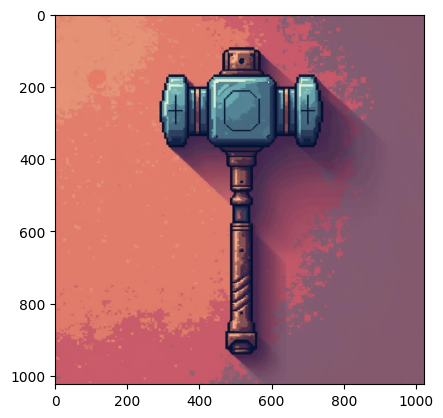

In [ ]:
# 예시 이미지 출력
random_image = plt.imread(f"{image_to_df['file_path'].iloc[0]}")
plt.imshow(random_image)

In [ ]:
print("전체데이터 갯수: ", len(image_to_df))
print("실제이미지 갯수: ", image_to_df['binary_label'].sum())
print("ai이미지 갯수: ", len(image_to_df)-image_to_df['binary_label'].sum())

전체데이터 갯수:  2000
실제이미지 갯수:  1000
ai이미지 갯수:  1000


In [ ]:
#중복확인
if not image_to_df['file_path'].duplicated().any() : 
    print("중복이 없습니다")
else : 
    print("중복이 있습니다")

중복이 없습니다


In [ ]:
ai_df = image_to_df[image_to_df["binary_label"] == False].reset_index()
real_df = image_to_df[image_to_df["binary_label"] == True].reset_index()

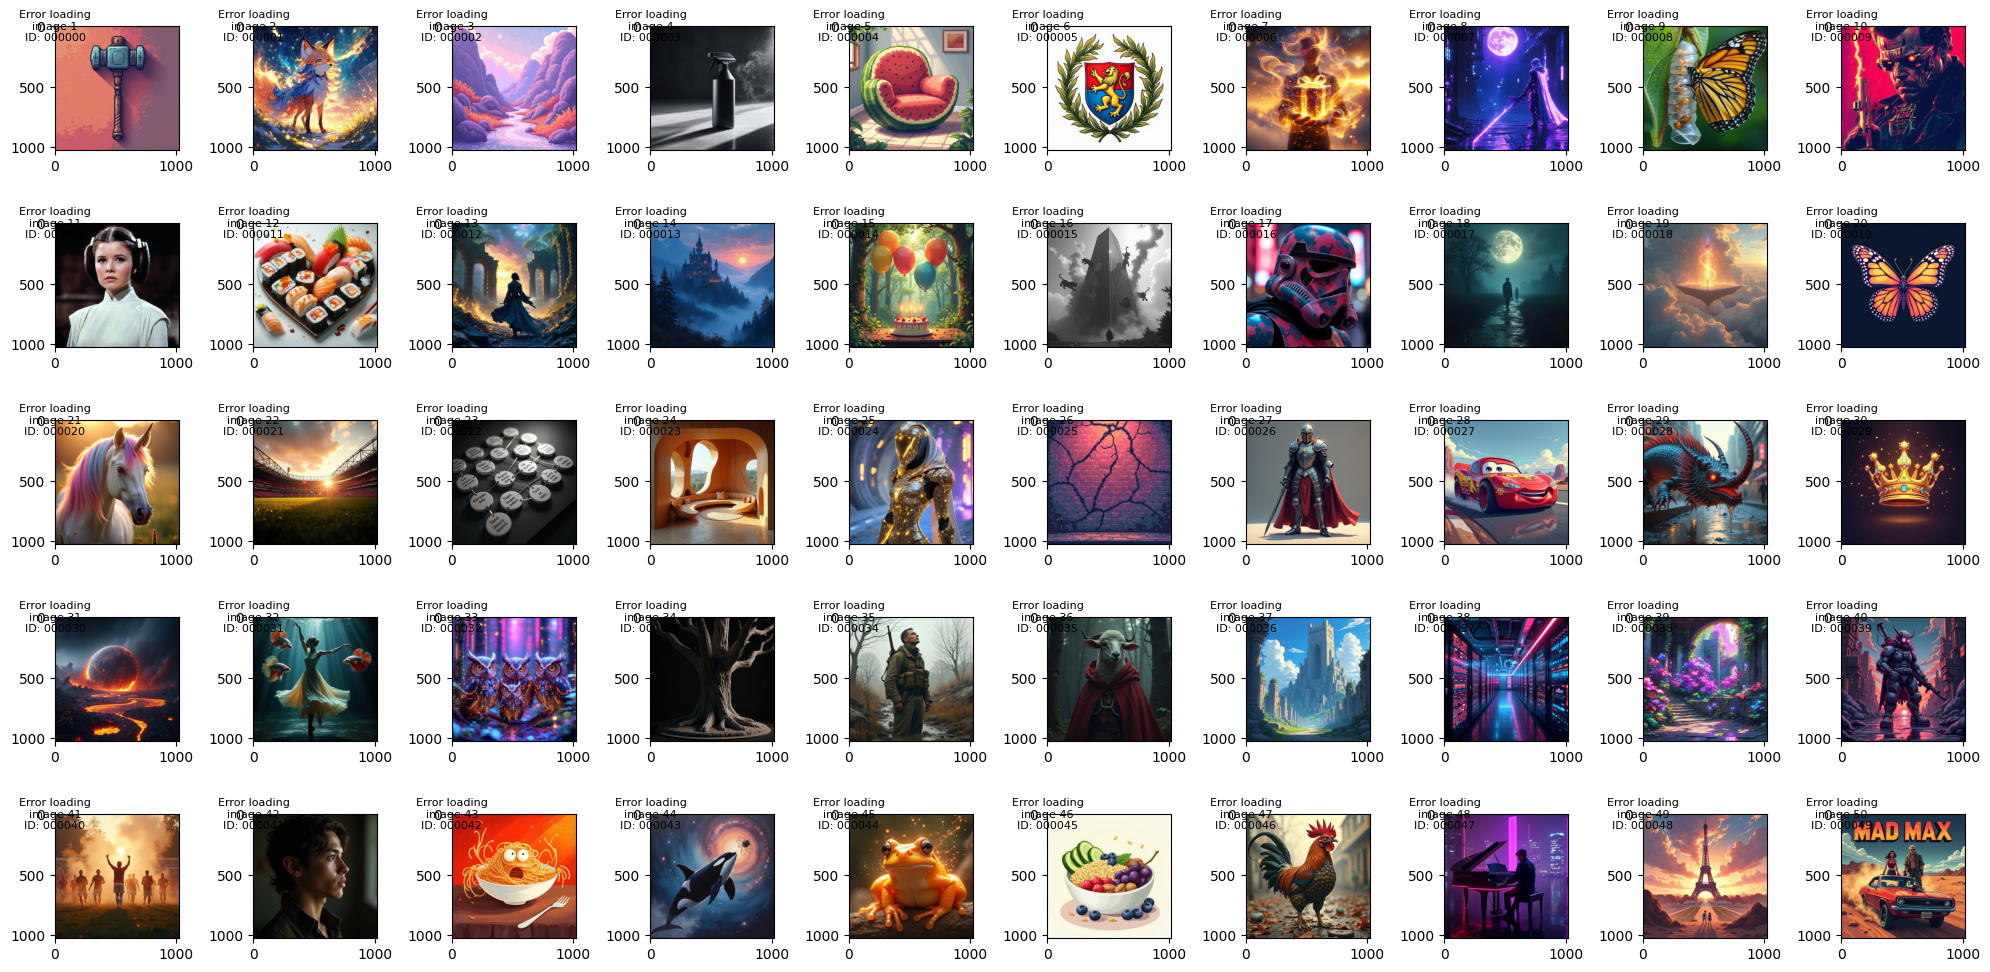


배치 1 세부 정보:

Batch Image 1
File ID: 000000
File Path: /workspace/ai-vs-real/train/ai/000000.jpg
Labels: 0

Batch Image 2
File ID: 000001
File Path: /workspace/ai-vs-real/train/ai/000001.jpg
Labels: 0

Batch Image 3
File ID: 000002
File Path: /workspace/ai-vs-real/train/ai/000002.jpg
Labels: 0

Batch Image 4
File ID: 000003
File Path: /workspace/ai-vs-real/train/ai/000003.jpg
Labels: 0

Batch Image 5
File ID: 000004
File Path: /workspace/ai-vs-real/train/ai/000004.jpg
Labels: 0

Batch Image 6
File ID: 000005
File Path: /workspace/ai-vs-real/train/ai/000005.jpg
Labels: 0

Batch Image 7
File ID: 000006
File Path: /workspace/ai-vs-real/train/ai/000006.jpg
Labels: 0

Batch Image 8
File ID: 000007
File Path: /workspace/ai-vs-real/train/ai/000007.jpg
Labels: 0

Batch Image 9
File ID: 000008
File Path: /workspace/ai-vs-real/train/ai/000008.jpg
Labels: 0

Batch Image 10
File ID: 000009
File Path: /workspace/ai-vs-real/train/ai/000009.jpg
Labels: 0

Batch Image 11
File ID: 000010
File Path: /wo

In [ ]:
# 이미지 확인

def display_image_batch(df, start_idx, batch_size=100):
    
    batch_df = df.iloc[start_idx:start_idx + batch_size]
    
    n_cols = 10
    n_rows = math.ceil(len(batch_df) / n_cols)
    
    plt.figure(figsize=(20, 2*n_rows))
    
    for idx, (_, row) in enumerate(batch_df.iterrows()):
        plt.subplot(n_rows, n_cols, idx + 1)
        try:
            img = mpimg.imread(row['file_path'])
            plt.imshow(img)
            # 제목에 file_id 추가
            plt.title(f'Batch {start_idx + idx + 1}\nID: {row["file_id"]}\nLabels: {row["labels"]}', 
                     fontsize=8)
            plt.axis('off')
        except Exception as e:
            plt.text(0.5, 0.5, f'Error loading\nimage {start_idx + idx + 1}\nID: {row["file_id"]}', 
                    ha='center', va='center', fontsize=8)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n배치 {start_idx//batch_size + 1} 세부 정보:")
    for idx, row in batch_df.iterrows():
        print(f"\nBatch Image {start_idx + idx + 1}")
        print(f"File ID: {row['file_id']}")
        print(f"File Path: {row['file_path']}")
        print(f"Labels: {row['binary_label']}")

ai_images = image_to_df[image_to_df["binary_label"] == False].reset_index()
total_images = len(ai_df)

start_idx = 0 
batch_size = 50 

display_image_batch(ai_images, start_idx, batch_size)

In [ ]:
# file_id에 ai/real 구분 추가
def make_new_id(row):
    base = os.path.splitext(os.path.basename(row["file_path"]))[0]
    if "/ai/" in row["file_path"] or "\\ai\\" in row["file_path"]:
        return f"ai_{base}"
    elif "/real/" in row["file_path"] or "\\real\\" in row["file_path"]:
        return f"real_{base}"
    else:
        return base

image_to_df["file_id"] = image_to_df.apply(make_new_id, axis=1)
image_to_df

,file_id,file_path,split,binary_label,is_real
0,ai_000000,/workspace/ai-vs-real/train/ai/000000.jpg,train,0,False
1,ai_000001,/workspace/ai-vs-real/train/ai/000001.jpg,train,0,False
2,ai_000002,/workspace/ai-vs-real/train/ai/000002.jpg,train,0,False
3,ai_000003,/workspace/ai-vs-real/train/ai/000003.jpg,train,0,False
4,ai_000004,/workspace/ai-vs-real/train/ai/000004.jpg,train,0,False
...,...,...,...,...,...
1995,real_000195,/workspace/ai-vs-real/test/real/000195.jpg,test,1,True
1996,real_000196,/workspace/ai-vs-real/test/real/000196.jpg,test,1,True
1997,real_000197,/workspace/ai-vs-real/test/real/000197.jpg,test,1,True
1998,real_000198,/workspace/ai-vs-real/test/real/000198.jpg,test,1,True


In [ ]:
image_to_df.to_csv("final_df.csv", index=False)
print("데이터 확인:" , image_to_df.shape)

데이터 확인: (2000, 5)
